# Generate Data and Intialise

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from core import FourierSynthesizer

target_letter = 'R'

synth = FourierSynthesizer.generate_and_load(
    letter=target_letter, 
    executable_path='./letter'
)

Setting execution permissions for ./letter...
Running executable to generate outline for 'R'...
Saved points to R.csv


# Visualise Static Reconstructions

Generating static reconstructions...


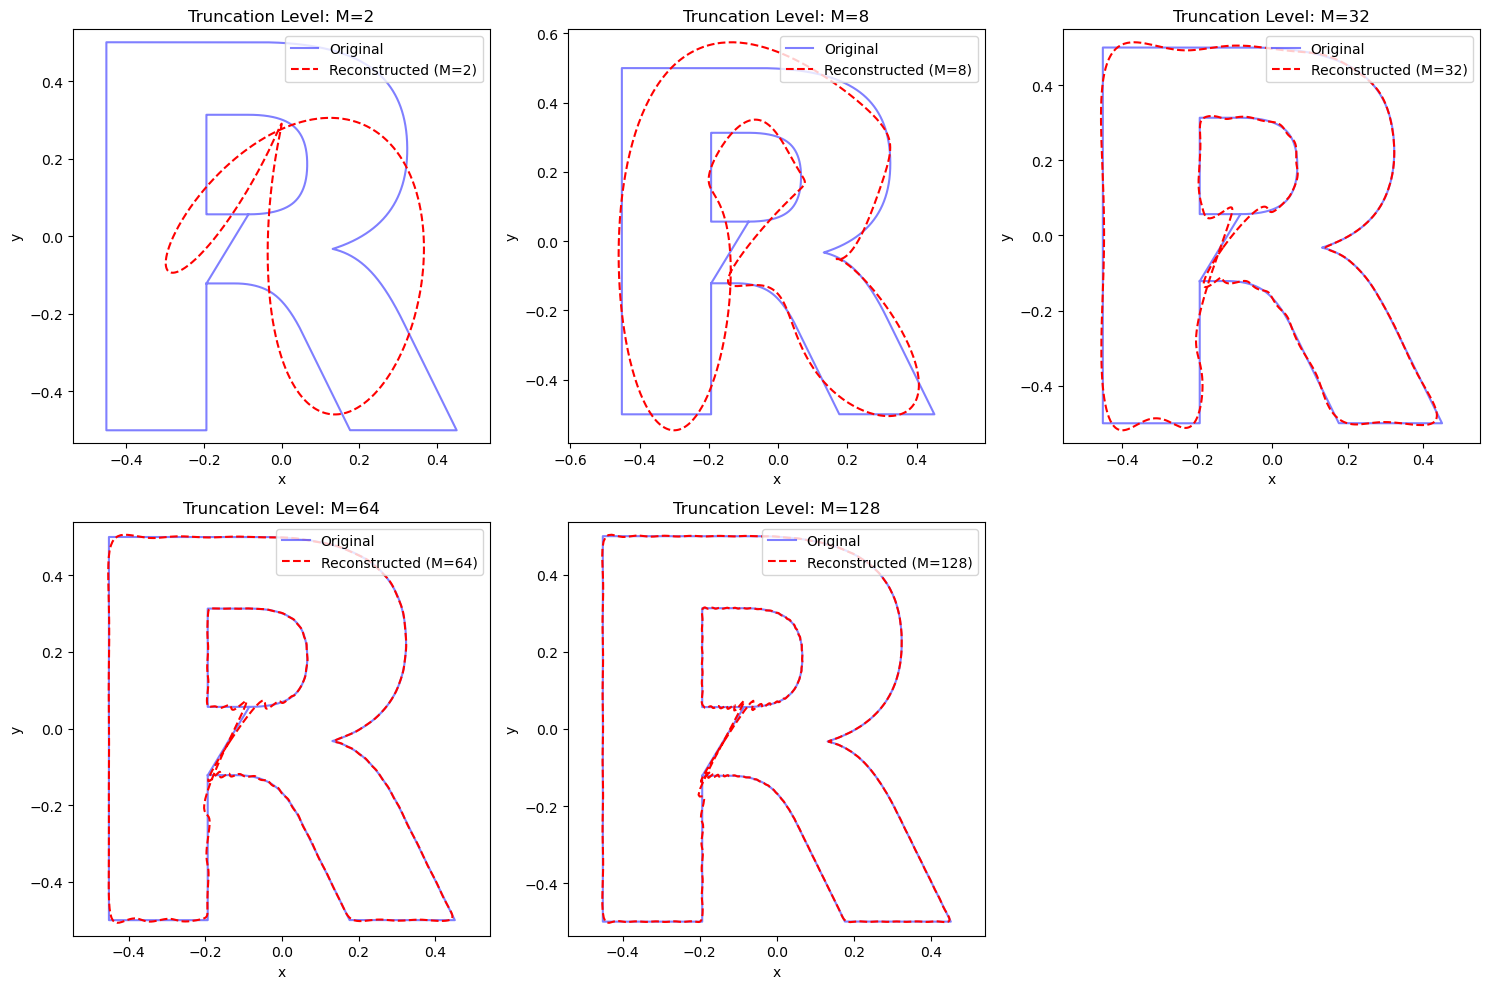

In [2]:
print("Generating static reconstructions...")
Ms = [2, 8, 32, 64, 128]
plt.figure(figsize=(15, 10))

for idx, M in enumerate(Ms):
    z_reconstructed = synth.reconstruct_shape(M)
    
    plt.subplot(2, 3, idx + 1)
    plt.plot(synth.z.real, synth.z.imag, label='Original', color='blue', alpha=0.5)
    plt.plot(z_reconstructed.real, z_reconstructed.imag, label=f'Reconstructed (M={M})', color='red', linestyle='--')
    plt.title(f'Truncation Level: M={M}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.legend()

plt.tight_layout()
plt.savefig(f'imgs/fourier_reconstruction_{target_letter}.png', dpi=300)
plt.show()

# Generate Fourier Epicycle Animation

In [3]:
print("Generating Fourier epicycle animation (this may take a minute)...")
M_anim = 128
c_k = synth.compute_coefficients(M_anim)
freqs = list(c_k.keys())

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f"Fourier Series Epicycle Reconstruction: {target_letter}")

ax.plot(synth.z.real, synth.z.imag, color='gray', alpha=0.3)

arms, = ax.plot([], [], 'b-', lw=1.2, alpha=0.6)
trace_line, = ax.plot([], [], 'r-', lw=1.5)
tip, = ax.plot([], [], 'ro', markersize=4)

trace_x, trace_y = [], []

def init():
    arms.set_data([], [])
    trace_line.set_data([], [])
    tip.set_data([], [])
    return arms, trace_line, tip

def update(frame):
    t = frame / 300
    z_sum = 0
    arm_x, arm_y = [0.0], [0.0]

    for k in freqs:
        z_sum += c_k[k] * np.exp(1j * 2 * np.pi * k * t)
        arm_x.append(z_sum.real)
        arm_y.append(z_sum.imag)

    trace_x.append(z_sum.real)
    trace_y.append(z_sum.imag)

    arms.set_data(arm_x, arm_y)
    trace_line.set_data(trace_x, trace_y)
    tip.set_data([z_sum.real], [z_sum.imag])
    
    return arms, trace_line, tip

anim = FuncAnimation(fig, update, init_func=init, frames=300, interval=20, blit=True)
anim.save(f"imgs/fourier_animation_{target_letter}.gif", writer=PillowWriter(fps=30))
print(f"Animation saved at imgs/fourier_animation_{target_letter}.gif!")
plt.close()

Generating Fourier epicycle animation (this may take a minute)...
Animation saved at imgs/fourier_animation_R.gif!
